# BANK77 String-Length Distribution by Category

This notebook loads BANKING77 (train + test), computes per-example string length, checks that all 77 categories are present, and renders a box-and-whisker plot for each category.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

BANK77_REVISION = "18072d2685ea682290f7b8924d94c62acc19c0b2"
BANK77_BASE_URL = f"https://huggingface.co/datasets/mteb/banking77/resolve/{BANK77_REVISION}"
BANK77_SPLIT_URLS = {
    "train": f"{BANK77_BASE_URL}/data/train-00000-of-00001.parquet",
    "test": f"{BANK77_BASE_URL}/data/test-00000-of-00001.parquet",
}

frames = []
for split, url in BANK77_SPLIT_URLS.items():
    frame = pd.read_parquet(url)
    frame["split"] = split
    frames.append(frame)

bank77 = pd.concat(frames, ignore_index=True)
if "text" not in bank77.columns:
    raise ValueError(f"Expected a 'text' column. Columns found: {list(bank77.columns)}")

bank77.head()

,text,label,label_text,split
0,I am still waiting on my card?,11,card_arrival,train
1,What can I do if my card still hasn't arrived ...,11,card_arrival,train
2,I have been waiting over a week. Is the card s...,11,card_arrival,train
3,Can I track my card while it is in the process...,11,card_arrival,train
4,"How do I know if I will get my card, or if it ...",11,card_arrival,train


In [2]:
category = None
for candidate in ("label_text", "intent", "label_name"):
    if candidate in bank77.columns:
        category = bank77[candidate].astype("string").str.strip()
        category = category.mask(category == "", pd.NA)
        break

if category is None:
    if "label" not in bank77.columns:
        raise ValueError("No category column found and no fallback 'label' column present.")
    category = "label_" + bank77["label"].astype("Int64").astype(str)
else:
    if "label" in bank77.columns:
        fallback = "label_" + bank77["label"].astype("Int64").astype(str)
        category = category.fillna(fallback)
    else:
        category = category.fillna("unknown")

bank77["category"] = category.astype(str)
bank77["char_length"] = bank77["text"].astype(str).str.len()

category_count = bank77["category"].nunique()
print(f"Unique categories found: {category_count}")
if category_count != 77:
    raise ValueError(f"Expected 77 categories, found {category_count}.")

summary = (
    bank77.groupby("category")["char_length"]
    .agg(
        count="size",
        min_len="min",
        q1=lambda s: s.quantile(0.25),
        median_len="median",
        q3=lambda s: s.quantile(0.75),
        max_len="max",
    )
    .sort_values("median_len")
)

summary

Unique categories found: 77


,count,min_len,q1,median_len,q3,max_len
category,,,,,,
get_physical_card,146,13,25.0,30.0,38.50,71
order_physical_card,160,18,28.0,33.0,40.25,98
top_up_limits,137,13,27.0,33.0,39.00,80
card_acceptance,99,20,29.0,34.0,44.50,68
atm_support,125,16,31.0,35.0,42.00,72
...,...,...,...,...,...,...
cash_withdrawal_not_recognised,200,22,49.0,60.5,94.25,207
compromised_card,126,26,46.0,61.0,84.75,321
balance_not_updated_after_cheque_or_cash_deposit,221,20,53.0,63.0,83.00,218


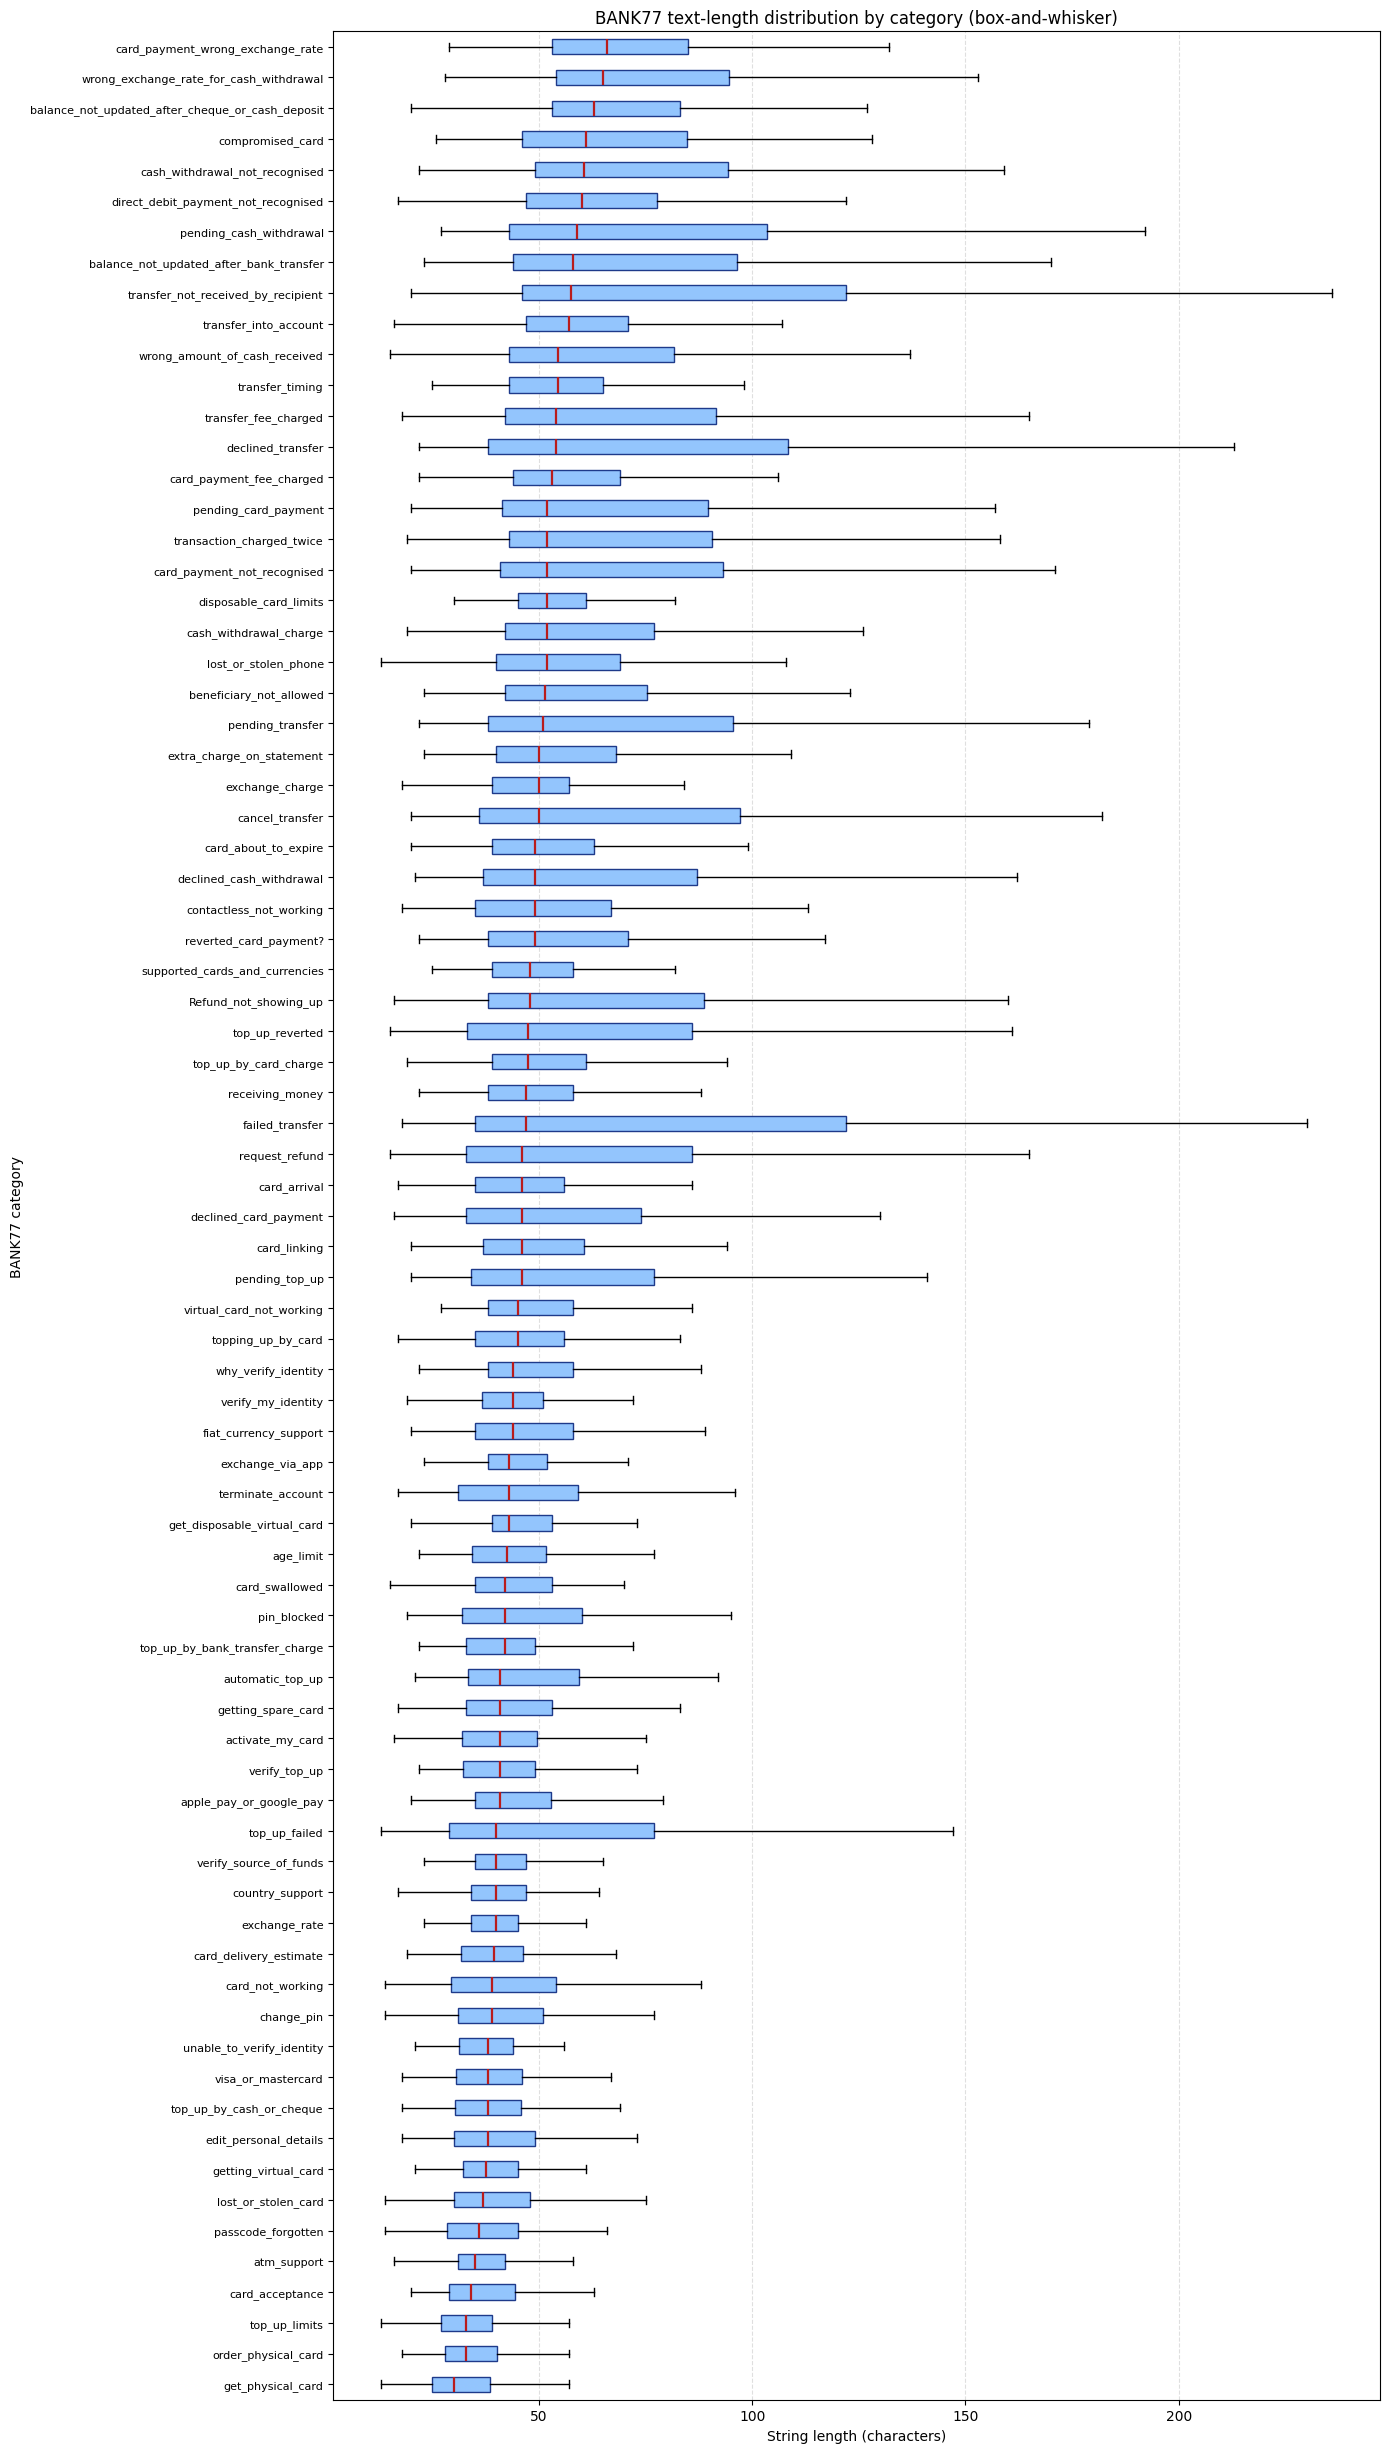

In [3]:
ordered_categories = summary.index.tolist()
grouped_lengths = [
    bank77.loc[bank77["category"] == category, "char_length"].to_numpy()
    for category in ordered_categories
]

fig_height = max(18, len(ordered_categories) * 0.32)
fig, ax = plt.subplots(figsize=(14, fig_height))

boxplot = ax.boxplot(
    grouped_lengths,
    vert=False,
    patch_artist=True,
    showfliers=False,
    whis=1.5,
)

for patch in boxplot["boxes"]:
    patch.set_facecolor("#93c5fd")
    patch.set_edgecolor("#1e3a8a")

for median in boxplot["medians"]:
    median.set_color("#b91c1c")
    median.set_linewidth(1.6)

ax.set_yticks(range(1, len(ordered_categories) + 1))
ax.set_yticklabels(ordered_categories, fontsize=8)
ax.set_xlabel("String length (characters)")
ax.set_ylabel("BANK77 category")
ax.set_title("BANK77 text-length distribution by category (box-and-whisker)")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()